In [1]:
rm(list = ls())
gc()

library(Seurat)
library(dplyr)

library("SymSim")


setwd('/mnt/data00/Minghui/project_NMF/10_simlate_count/')

cluster_cols <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72",
  "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", "#E78AC3",
  "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D",
  "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000",
  "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,634147,33.9,1390690,74.3,1064745,56.9
Vcells,1176751,9.0,8388608,64.0,1815604,13.9


Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: plyr

------------------------------------------------------------------------------

You have loaded plyr after dplyr - this is likely to cause problems.
If you need functions from both plyr and dplyr, please load plyr first, then dplyr:
library(plyr); library(dplyr)

------------------------------------------------------------------------------


Attaching package: ‘plyr’


The following objects are masked from ‘package:dplyr’:

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize


Loading required package: ggplot2

Loading required package: Rtsne

Loading r

### 24000 cells 7000 genes 3 tractories

In [3]:
count1 <- readRDS('./02_count1.rds')

count2 <- readRDS('./02_count2.rds')

count3 <- readRDS('./02_count3.rds')

### add batches

In [4]:
my_batch <- function(observed_counts, nbatch, batch_effect_size,seed){
    meta_cell <- as.data.frame(as.factor(colnames(observed_counts)))
    ncells <- dim(observed_counts)[2]
    ngenes <- dim(observed_counts)[1]

set.seed(seed)
# nbatch <- 4 
batchIDs <- sample(1:nbatch, ncells, replace = TRUE)

meta_cell2 <- data.frame(batch = batchIDs, stringsAsFactors = F)
meta_cell <- cbind(meta_cell, meta_cell2)
colnames(meta_cell) <- c('cellID','batch')

    mean_matrix <- matrix(0, ngenes, nbatch)
    gene_mean <- rnorm(ngenes, 0, 1)


batch_effect_size <-batch_effect_size
temp <- lapply(1:ngenes, function(igene) {
        return(runif(nbatch, min = gene_mean[igene] - batch_effect_size, 
            max = gene_mean[igene] + batch_effect_size))
    })

 mean_matrix <- do.call(rbind, temp)

batch_factor <- matrix(0, ngenes, ncells)
    for (igene in 1:ngenes) {
        for (icell in 1:ncells) {
            batch_factor[igene, icell] <- rnorm(n = 1, mean = mean_matrix[igene, 
                batchIDs[icell]], sd = 0.01)
        }
    }

count1_b <- round(2^(log2(observed_counts) + batch_factor))

    obj <- list(count1_b,meta_cell)
    
    names(obj) <- c('count','batch_label')

    return(obj)
    
}

In [19]:
test <- my_batch(observed_counts = count1,nbatch = 5,batch_effect_size = 0.1,seed = 123)

test2 <- my_batch(observed_counts = count2,nbatch = 6,batch_effect_size = 0.05,seed = 123)

test3 <- my_batch(observed_counts = count3,nbatch = 2,batch_effect_size = 0.001,seed = 123)

In [20]:
count_mat_b <- cbind(cbind(test$count,test2$count ),test3$count)

In [21]:
count_mat_b[1:10,1:5]

test$batch_label %>% head()

,cell1,cell2,cell3,cell4,cell5
gene1,9,1,5,8,4
gene2,1375,1534,1172,1690,816
gene3,2,28,5,6,2
gene4,74,121,57,106,26
gene5,36,15,43,17,49
gene6,0,0,0,0,0
gene7,105,94,74,64,65
gene8,15,2,17,6,3
gene9,119,107,115,104,114
gene10,5,91,12,97,81


,cellID,batch
,<fct>,<int>
1,cell1,3
2,cell2,3
3,cell3,2
4,cell4,2
5,cell5,3
6,cell6,5


In [22]:
meta_data1 <- test$batch_label

meta_data1$batch <- paste0('1_',meta_data1$batch)

meta_data2 <- test2$batch_label

meta_data2$batch <- paste0('2_',meta_data2$batch)

meta_data3 <- test3$batch_label

meta_data3$batch <- paste0('3_',meta_data3$batch)

metalabel <-rbind( rbind(meta_data1,meta_data2),meta_data3)

rownames(metalabel) <- metalabel$cellID
tail(metalabel)

,cellID,batch
,<fct>,<chr>
tcell7995,tcell7995,3_2
tcell7996,tcell7996,3_2
tcell7997,tcell7997,3_1
tcell7998,tcell7998,3_1
tcell7999,tcell7999,3_2
tcell8000,tcell8000,3_1


In [23]:
seurat_obj <- CreateSeuratObject(counts = count_mat_b,meta.data = metalabel)


seurat_obj <- NormalizeData(seurat_obj) %>%

    FindVariableFeatures( selection.method = "vst", nfeatures = 3000)%>%

    ScaleData()

seurat_obj <- RunPCA(seurat_obj, npcs = 50, verbose = FALSE)

Centering and scaling data matrix



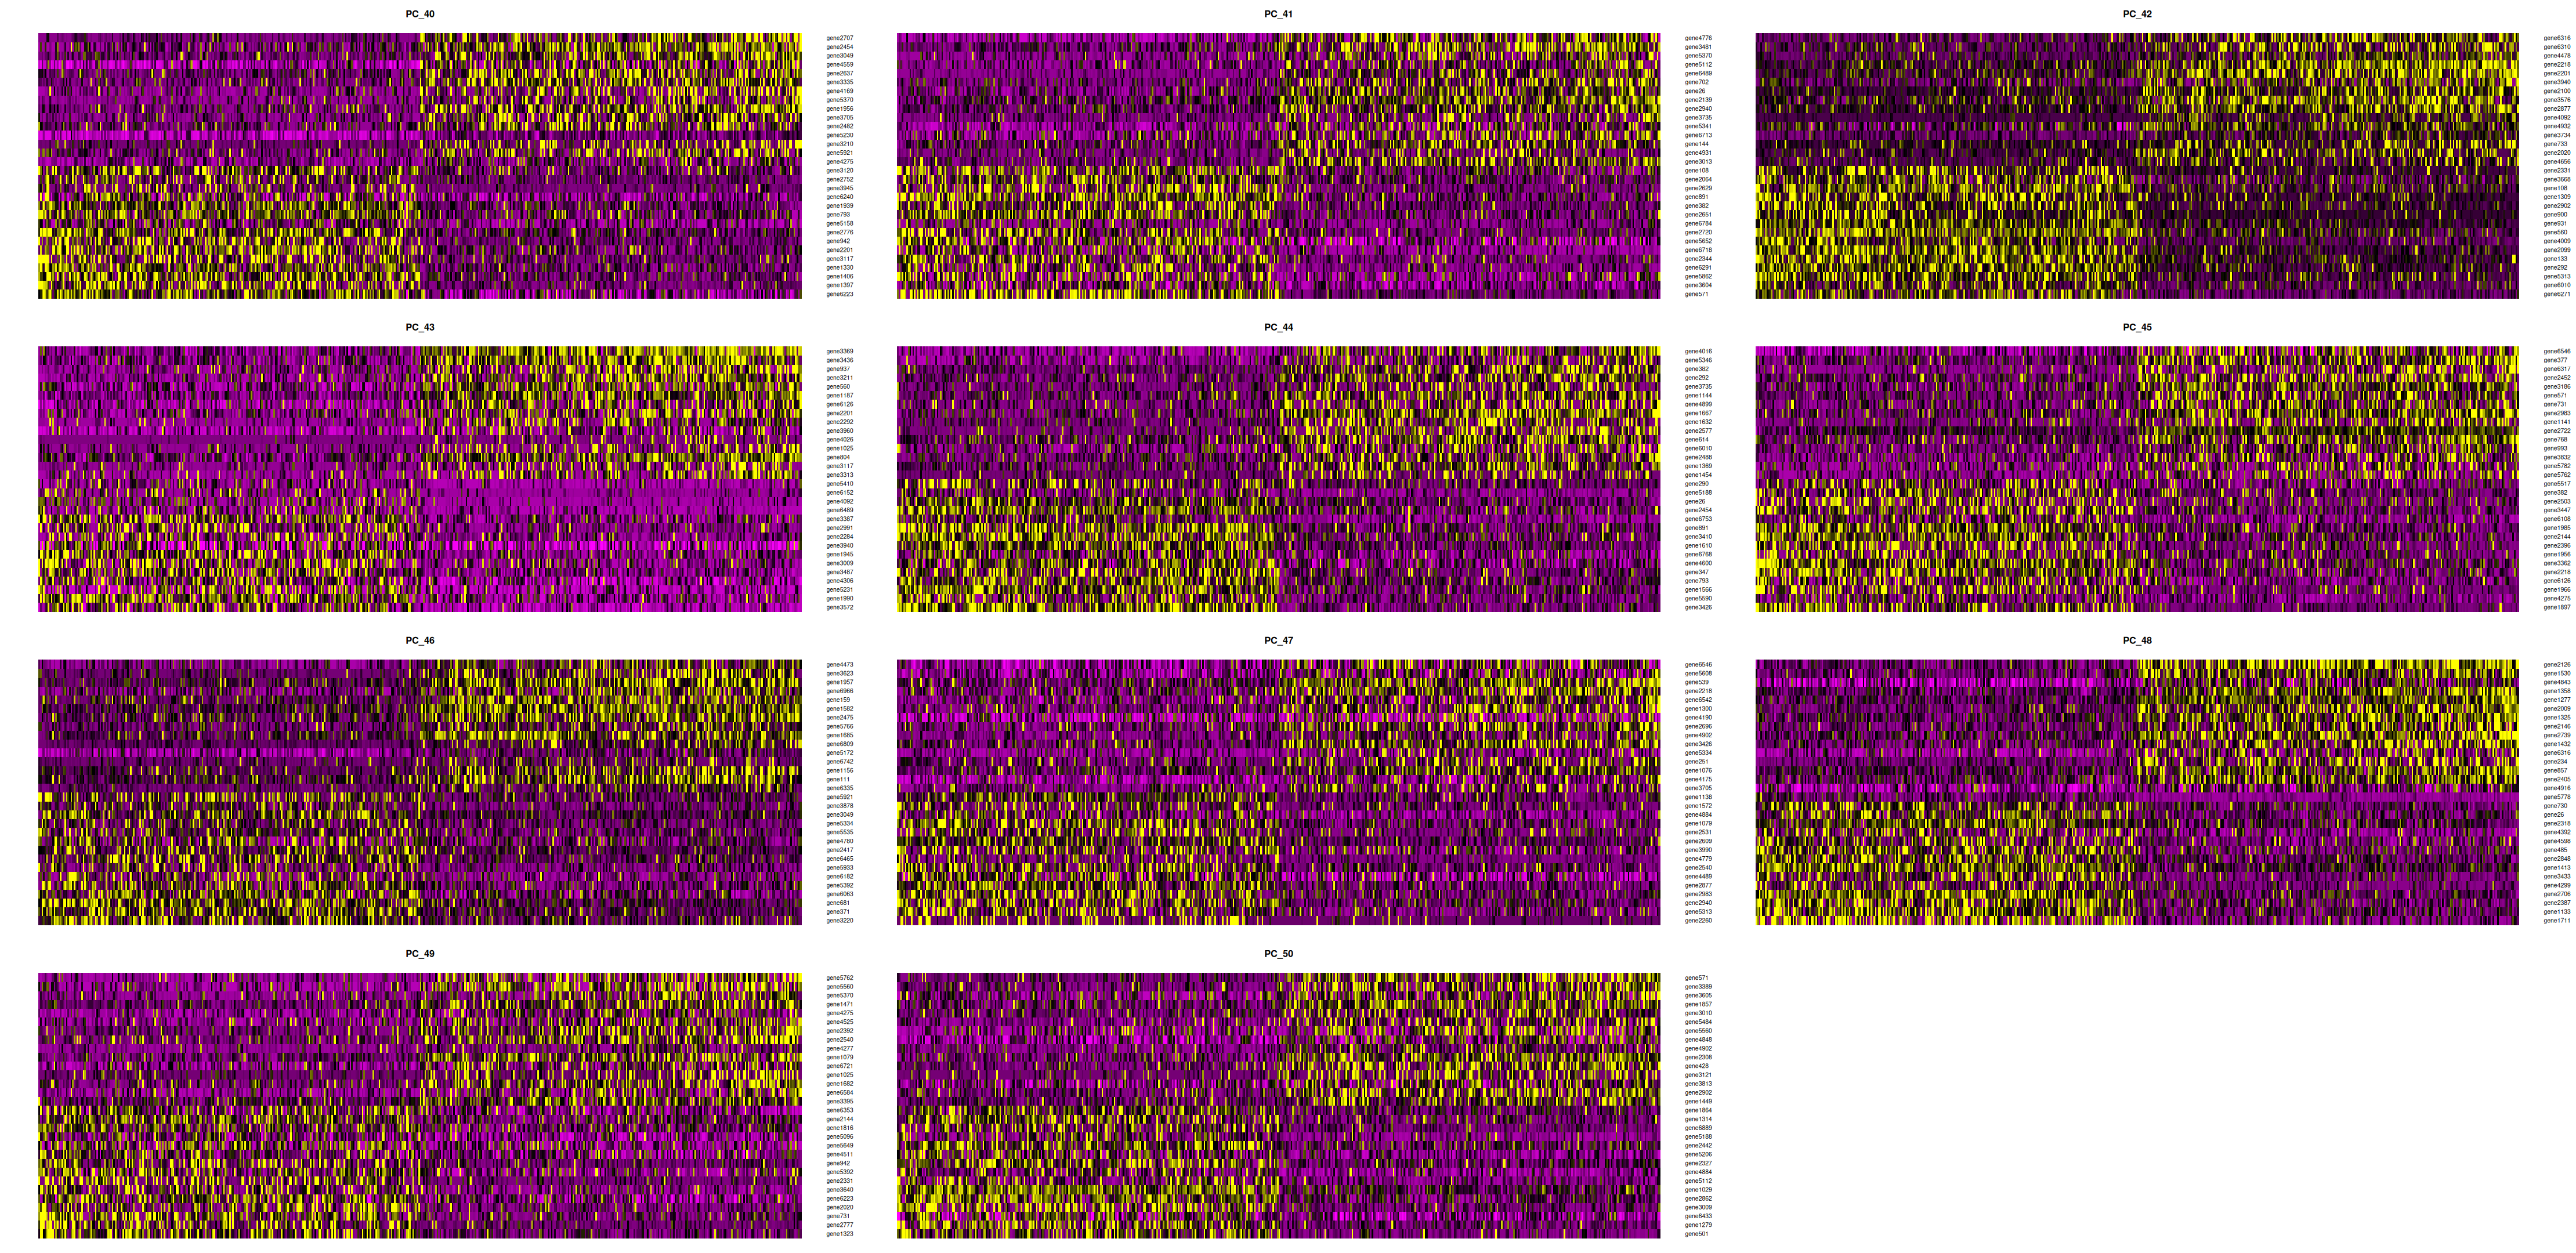

In [24]:
options(repr.plot.width =37, repr.plot.height=18)


DimHeatmap(seurat_obj, dims = 40:50, cells = 500, balanced = TRUE)

In [ ]:
seurat_sim <- FindNeighbors(seurat_obj,dims = 1:50,reduction = 'pca') %>%

FindClusters(resolution = 0.5) %>%

RunUMAP( dims = 1:50) %>% RunTSNE()

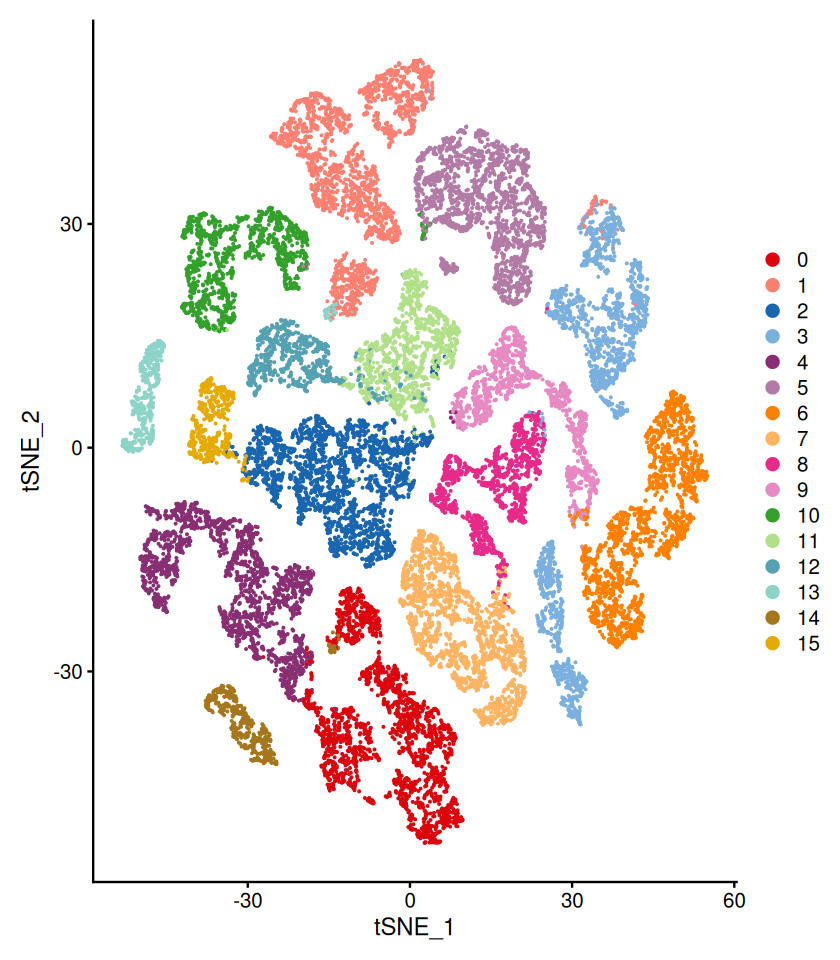

In [26]:
options(repr.plot.width =7, repr.plot.height=8)

DimPlot(seurat_sim, reduction = 'tsne', label = FALSE,cols = cluster_cols)  # batch


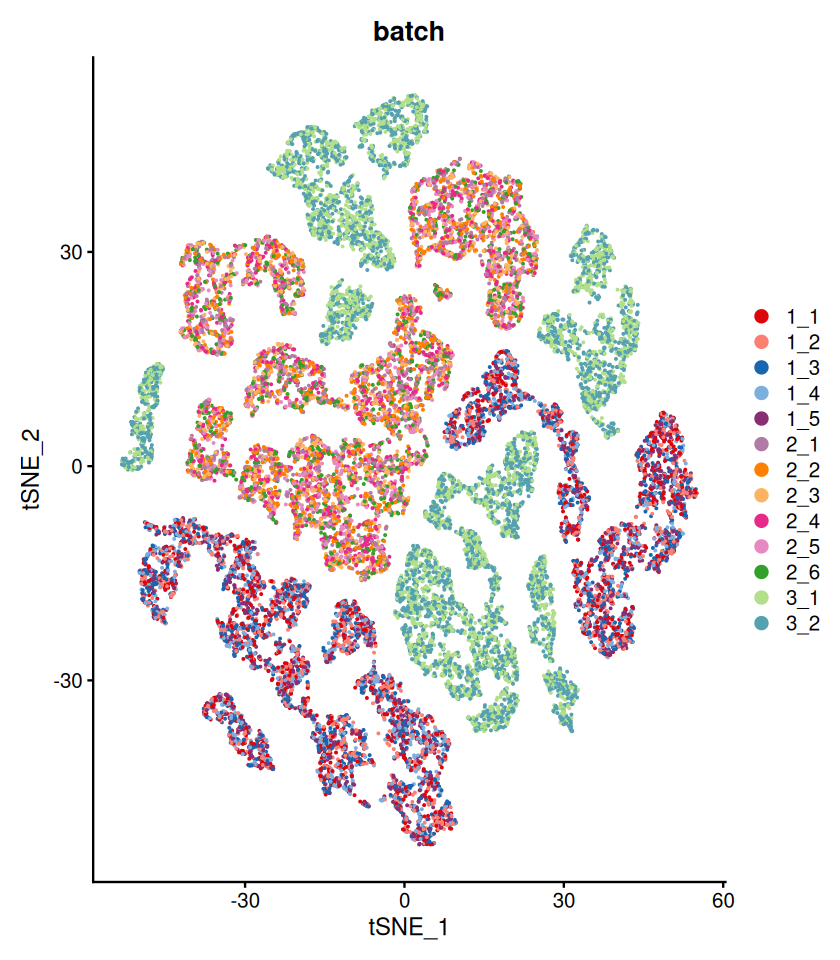

In [27]:
options(repr.plot.width =7, repr.plot.height=8)

DimPlot(seurat_sim, reduction = 'tsne', group.by ='batch',
        label = FALSE,cols = cluster_cols)  # batch


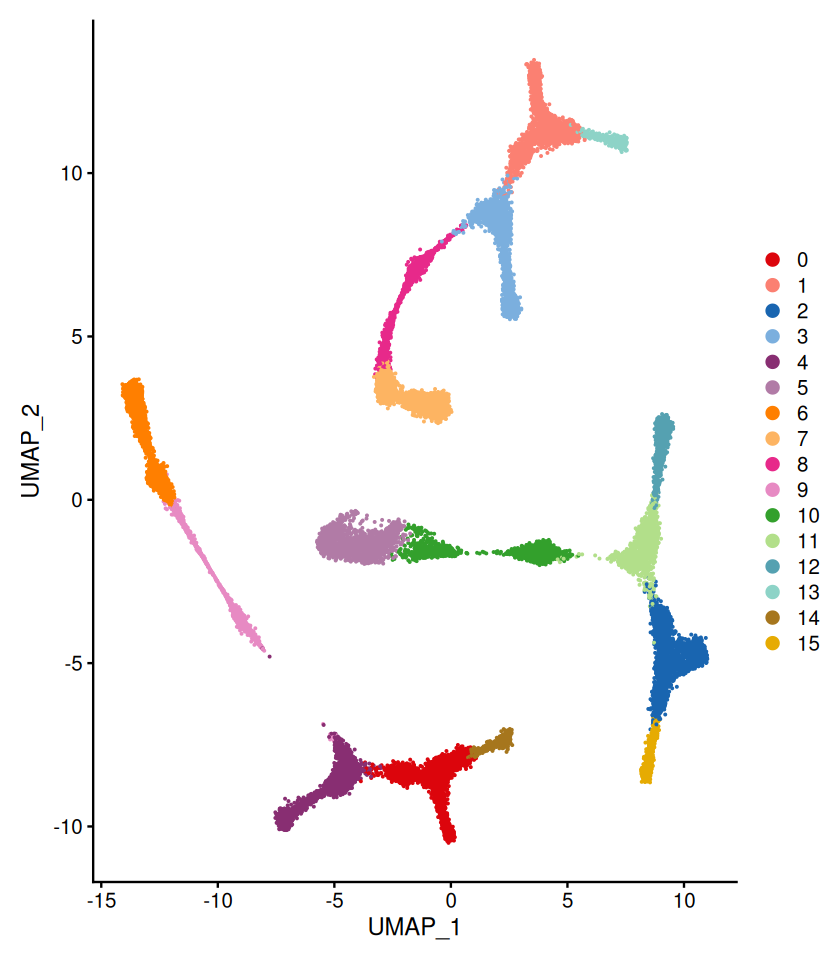

In [28]:
options(repr.plot.width =7, repr.plot.height=8)

DimPlot(seurat_sim, reduction = 'umap', 
        label = FALSE,cols = cluster_cols)  # batch


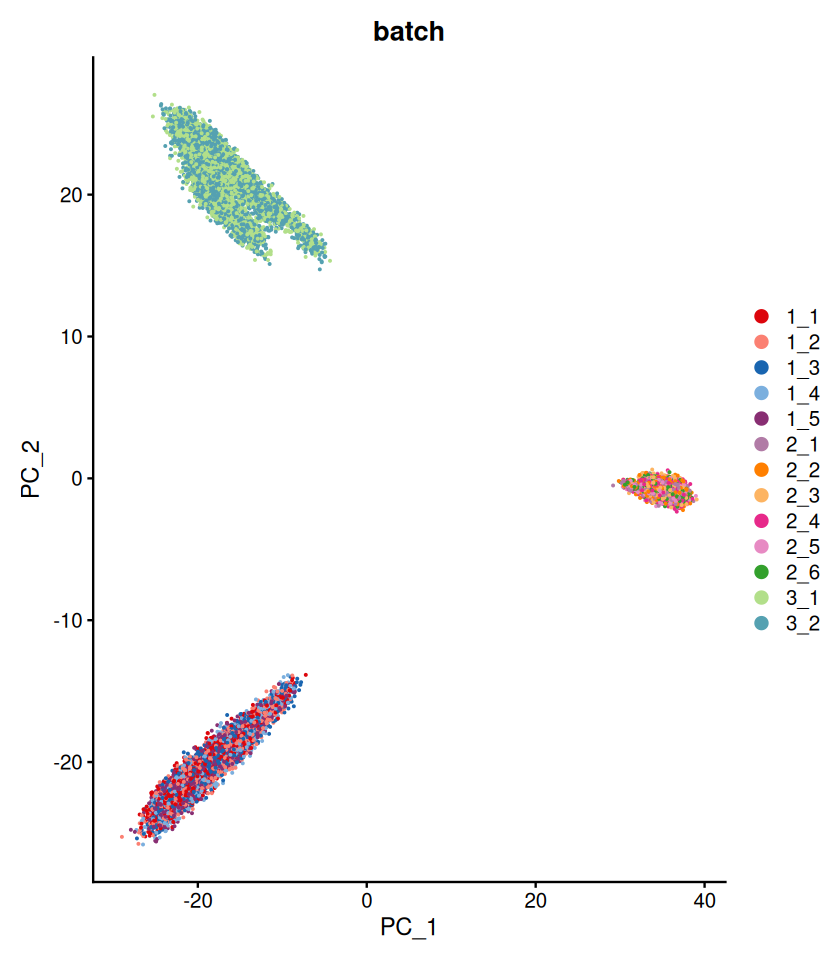

In [29]:
options(repr.plot.width =7, repr.plot.height=8)

# DimPlot(combined_seurat_filtered, group.by = c("seurat_clusters", "batch","Cell_Type" ), reduction = 'umap',label = FALSE)  # group
DimPlot(seurat_sim, reduction = 'pca', label = FALSE,group.by = 'batch',cols = cluster_cols)  # batch
#  DimPlot(sesplater_sim,group.by = "Cell_Type", label = FALSE)                      # cluster

In [30]:
library(splatter)

Loading required package: SingleCellExperiment



In [32]:
splatSimulate

function (params = newSplatParams(), method = c("single", "groups", 
    "paths"), sparsify = TRUE, verbose = TRUE, ...) 
{
    checkmate::assertClass(params, "SplatParams")
    method <- match.arg(method)
    if (verbose) {
        message("Getting parameters...")
    }
    params <- setParams(params, ...)
    params <- expandParams(params)
    validObject(params)
    seed <- getParam(params, "seed")
    withr::with_seed(seed, {
        nCells <- getParam(params, "nCells")
        nGenes <- getParam(params, "nGenes")
        nBatches <- getParam(params, "nBatches")
        batch.cells <- getParam(params, "batchCells")
        nGroups <- getParam(params, "nGroups")
        group.prob <- getParam(params, "group.prob")
        if (nGroups == 1 && method == "groups") {
            warning("nGroups is 1, switching to single mode")
            method <- "single"
        }
        if (verbose) {
            message("Creating simulation object...")
        }
        cell.names <- paste0("Cell", seq_len(nCells))
        gene.names <- paste0("Gene", seq_len(nGenes))
        batch.names <- paste0("Batch", seq_len(nBatches))
        if (method == "groups") {
            group.names <- paste0("Group", seq_len(nGroups))
        }
        else if (method == "paths") {
            group.names <- paste0("Path", seq_len(nGroups))
        }
        cells <- data.frame(Cell = cell.names)
        rownames(cells) <- cell.names
        features <- data.frame(Gene = gene.names)
        rownames(features) <- gene.names
        sim <- SingleCellExperiment(rowData = features, colData = cells, 
            metadata = list(Params = params))
        batches <- lapply(seq_len(nBatches), function(i, b) {
            rep(i, b[i])
        }, b = batch.cells)
        batches <- unlist(batches)
        colData(sim)$Batch <- batch.names[batches]
        if (method != "single") {
            groups <- sample(seq_len(nGroups), nCells, prob = group.prob, 
                replace = TRUE)
            colData(sim)$Group <- factor(group.names[groups], 
                levels = group.names)
        }
        if (verbose) {
            message("Simulating library sizes...")
        }
        sim <- splatSimLibSizes(sim, params)
        if (verbose) {
            message("Simulating gene means...")
        }
        sim <- splatSimGeneMeans(sim, params)
        if (nBatches > 1) {
            if (verbose) {
                message("Simulating batch effects...")
            }
            sim <- splatSimBatchEffects(sim, params)
        }
        sim <- splatSimBatchCellMeans(sim, params)
        if (method == "single") {
            sim <- splatSimSingleCellMeans(sim, params)
        }
        else if (method == "groups") {
            if (verbose) {
                message("Simulating group DE...")
            }
            sim <- splatSimGroupDE(sim, params)
            if (verbose) {
                message("Simulating cell means...")
            }
            sim <- splatSimGroupCellMeans(sim, params)
        }
        else {
            if (verbose) {
                message("Simulating path endpoints...")
            }
            sim <- splatSimPathDE(sim, params)
            if (verbose) {
                message("Simulating path steps...")
            }
            sim <- splatSimPathCellMeans(sim, params)
        }
        if (verbose) {
            message("Simulating BCV...")
        }
        sim <- splatSimBCVMeans(sim, params)
        if (verbose) {
            message("Simulating counts...")
        }
        sim <- splatSimTrueCounts(sim, params)
        if (verbose) {
            message("Simulating dropout (if needed)...")
        }
        sim <- splatSimDropout(sim, params)
        if (sparsify) {
            if (verbose) {
                message("Sparsifying assays...")
            }
            assays(sim) <- sparsifyMatrices(assays(sim), auto = TRUE, 
                verbose = verbose)
        }
    })
    if (verbose) {
        message("Done!")
  

In [34]:
?rlnorm